In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 질량행렬
m1 = 10 # ton
m2 = 10
m3 = 10

# 대각행렬 만들기
M = np.diag([m1, m2, m3])
print(M)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [3]:
# 강성행렬
k1 = 2500*10
k2 = k1
k3 = k1

K = np.array([[k1+k2, -k2, 0],
             [-k2,k2+k3,-k3],
             [0,-k3,k3]])
print(K)

[[ 50000 -25000      0]
 [-25000  50000 -25000]
 [     0 -25000  25000]]


In [4]:
# 자유도 수
ndof = len(M)
print(ndof)

3


In [5]:
# 감쇠비 5%
xi = 0.05


In [6]:
from scipy.linalg import eigh

# 고유값 lamda, 고유벡터(모드형상) phi
lamda, phi = eigh(K, M)

print("고유값:\n", np.diag(lamda))
print("고유벡터:\n", phi)

고유값:
 [[ 495.15566049    0.            0.        ]
 [   0.         3887.39533022    0.        ]
 [   0.            0.         8117.44900929]]
고유벡터:
 [[ 0.10371805 -0.23305235 -0.18689347]
 [ 0.18689347 -0.10371805  0.23305235]
 [ 0.23305235  0.18689347 -0.10371805]]


In [7]:
np.diag(lamda)

array([[ 495.15566049,    0.        ,    0.        ],
       [   0.        , 3887.39533022,    0.        ],
       [   0.        ,    0.        , 8117.44900929]])

In [8]:
np.dot(phi[:,0],phi[:,1]), np.dot(phi[:,0],phi[:,2]), np.dot(phi[:,1],phi[:,2])

(np.float64(-9.934884450158001e-18),
 np.float64(-8.149114473003875e-18),
 np.float64(1.125803352763523e-17))

In [9]:
# 고유벡터의 정규화: 최상층변위를 1로 정규화
phi_n = np.zeros_like(phi)
for j in range(ndof):
  phi_n[:,j] = phi[:,j]/phi[-1,j]

print("Eigenmode: ",phi_n)
print("Normalized Mass: ", phi_n.T@M@phi_n)
print("Normalized Stiffness: ", phi_n.T@K@phi_n)

Eigenmode:  [[ 0.44504187 -1.2469796   1.80193774]
 [ 0.80193774 -0.55495813 -2.2469796 ]
 [ 1.          1.          1.        ]]
Normalized Mass:  [[ 1.84116640e+01 -1.77635684e-15  1.77635684e-15]
 [-3.55271368e-15  2.86293666e+01 -7.10542736e-15]
 [ 1.77635684e-15 -7.10542736e-15  9.29589694e+01]]
Normalized Stiffness:  [[ 9.11663963e+03 -2.72848411e-12 -7.27595761e-12]
 [ 0.00000000e+00  1.11293666e+05 -8.00355338e-11]
 [ 0.00000000e+00 -7.27595761e-11  7.54589694e+05]]


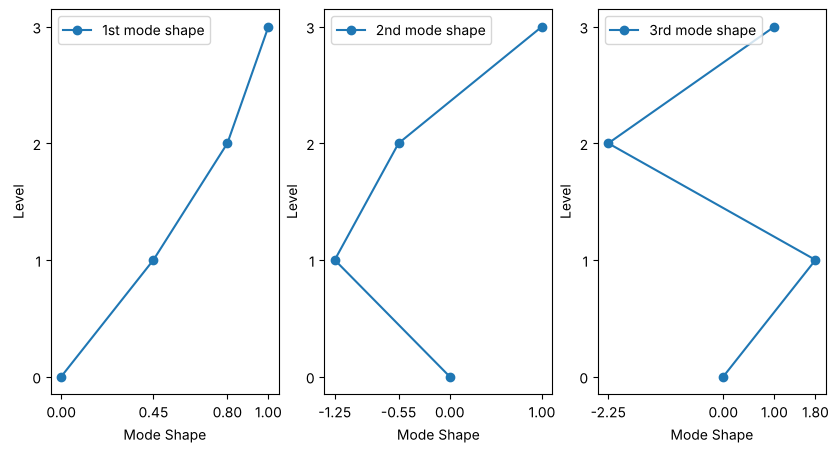

In [10]:
# 고유벡터 시각화
temp = np.zeros((1,ndof))
x = np.vstack((temp,phi_n))
y = np.arange(ndof+1)

plt.figure(figsize=(10,5))
plt.subplot(1, 3, 1)
plt.plot(x[:,0], y, marker='o',label='1st mode shape')
plt.xlabel('Mode Shape')
plt.ylabel('Level')
plt.legend()
#plt.xticks(x[:,0])
plt.xticks(x[:, 0], labels=[f"{val:.2f}" for val in x[:, 0]])
plt.yticks(y)

plt.subplot(1, 3, 2)
plt.plot(x[:,1], y, marker='o',label = '2nd mode shape')
plt.xlabel('Mode Shape')
plt.ylabel('Level')
plt.legend()
#plt.xticks(x[:,1])
plt.xticks(x[:, 1], labels=[f"{val:.2f}" for val in x[:, 1]])
plt.yticks(y)

plt.subplot(1, 3, 3)
plt.plot(x[:,2], y, marker='o',label = '3rd mode shape')
plt.xlabel('Mode Shape')
plt.ylabel('Level')
plt.legend()
#plt.xticks(x[:,1])
plt.xticks(x[:, 2], labels=[f"{val:.2f}" for val in x[:, 2]])
plt.yticks(y)

plt.show()

In [11]:
wn = np.diag(np.sqrt(lamda))
print('고유진동수')
print(wn)
Tn = 2*np.pi/np.diag(wn)
print('고유주기')
print(Tn)

고유진동수
[[22.2520934   0.          0.        ]
 [ 0.         62.34898019  0.        ]
 [ 0.          0.         90.09688679]]
고유주기
[0.28236378 0.10077447 0.0697381 ]


> **[수정 2026-10]** 감쇠행렬 C를 모드감쇠 5%에서 유도하도록 바꿨습니다. 기존 `C = 2*xi*wn*M`은 원소별 곱이어서 층마다 다른 감쇠가 들어갔고, `Cn` 대신 `C`를 출력했습니다. 아래 응답스펙트럼 해석(Γ, SRSS) 결과는 C를 쓰지 않으므로 바뀌지 않습니다.

In [12]:
Mn = phi_n.T @ M @ phi_n # 일반화 질량
Kn = phi_n.T @ K @ phi_n # 일반화 강성

# [수정 2026-10] 모드감쇠 5%를 물리좌표 감쇠행렬로 변환
# 기존: C = 2*xi*wn*M  -> 원소별 곱이라 층마다 다른 대각행렬이 되어 모드감쇠 5%가 아님
# 수정: Cn = diag(2*xi*w_n*Mn_n) 를 먼저 정하고  C = M·Φ·diag(2ξω_n/Mn_n)·Φᵀ·M
w = np.sqrt(lamda)                                   # 모드별 고유각진동수 (벡터)
Mn_d = np.diag(Mn)
C = M @ phi_n @ np.diag(2*xi*w/Mn_d) @ phi_n.T @ M   # 감쇠행렬 (물리좌표)
Cn = phi_n.T @ C @ phi_n                             # 일반화 감쇠 (대각이어야 함)

print('일반화 질량 Mn : \n', Mn)
print('일반화 강성 Kn : \n', Kn)
print('감쇠행렬 C : \n', C)
print('일반화 감쇠 Cn : \n', Cn)
print('모드별 감쇠비 확인 (모두 0.05여야 함):', np.diag(Cn)/(2*w*Mn_d))

일반화 질량 Mn : 
 [[ 1.84116640e+01 -1.77635684e-15  1.77635684e-15]
 [-3.55271368e-15  2.86293666e+01 -7.10542736e-15]
 [ 1.77635684e-15 -7.10542736e-15  9.29589694e+01]]
일반화 강성 Kn : 
 [[ 9.11663963e+03 -2.72848411e-12 -7.27595761e-12]
 [ 0.00000000e+00  1.11293666e+05 -8.00355338e-11]
 [ 0.00000000e+00 -7.27595761e-11  7.54589694e+05]]
감쇠행렬 C : 
 [[ 67.7276973  -19.85833908  -4.31339623]
 [-19.85833908  63.41430108 -24.17173531]
 [ -4.31339623 -24.17173531  43.55596199]]
일반화 감쇠 Cn : 
 [[ 4.09698066e+01 -2.13162821e-14  2.84217094e-14]
 [-2.84217094e-14  1.78501181e+02 -6.39488462e-14]
 [ 4.26325641e-14 -5.68434189e-14  8.37531375e+02]]
모드별 감쇠비 확인 (모두 0.05여야 함): [0.05 0.05 0.05]


In [13]:
# 하중 정의

Eq = np.loadtxt('elcentro.txt')  # 지진하중
xg = Eq[:,1]*9.81

F = xg  # 지진하중

F = xg  # 지진하중

In [14]:
T = Eq[:,0].T
nstep = len(T)
print(nstep)

2688


In [15]:
Eq

array([[ 0.0000000e+00, -1.4275799e-03],
       [ 2.0000000e-02, -1.1012760e-02],
       [ 4.0000000e-02, -1.0298970e-02],
       ...,
       [ 5.3700000e+01, -3.7728899e-03],
       [ 5.3720000e+01, -2.6512198e-03],
       [ 5.3740000e+01, -1.4275799e-03]], shape=(2688, 2))

In [16]:
dt = T[1]-T[0]
print(dt)

0.02


In [17]:
#상태방정식
from scipy.signal import cont2discrete


iM = np.linalg.inv(M) # 질량 행렬의 역행렬

A1 = np.hstack((np.zeros((ndof,ndof)) , np.eye(ndof)))
A2 = np.hstack((-iM@K, -iM@C))
A = np.vstack((A1,A2))

B = np.array([np.zeros((ndof,1)),-np.ones((ndof,1))]).reshape((2*ndof,1))

system = (A, B, None, None)
sys_discrete = cont2discrete(system, dt)
Ad, Bd= sys_discrete[0], sys_discrete[1]

print(Ad)
print(Bd)

[[ 2.27721377e-01  3.29512399e-01  3.67314254e-02  1.32551972e-02
   2.81562035e-03  2.64075065e-04]
 [ 3.29512399e-01  2.64452803e-01  3.66243825e-01  2.81562035e-03
   1.35192722e-02  3.07969541e-03]
 [ 3.67314254e-02  3.66243825e-01  5.93965202e-01  2.64075065e-04
   3.07969541e-03  1.63348926e-02]
 [-5.92369351e+01  1.97200789e+01  6.37886320e+00  1.43652239e-01
   3.38618275e-01  4.81045558e-02]
 [ 1.97200789e+01 -5.28580719e+01  2.60989421e+01  3.38618275e-01
   1.91756795e-01  3.86722831e-01]
 [ 6.37886320e+00  2.60989421e+01 -3.31379930e+01  4.81045558e-02
   3.86722831e-01  5.30375070e-01]]
[[-0.00017955]
 [-0.00019669]
 [-0.00019792]
 [-0.01633489]
 [-0.01941459]
 [-0.01967866]]


In [18]:
Ad

array([[ 2.27721377e-01,  3.29512399e-01,  3.67314254e-02,
         1.32551972e-02,  2.81562035e-03,  2.64075065e-04],
       [ 3.29512399e-01,  2.64452803e-01,  3.66243825e-01,
         2.81562035e-03,  1.35192722e-02,  3.07969541e-03],
       [ 3.67314254e-02,  3.66243825e-01,  5.93965202e-01,
         2.64075065e-04,  3.07969541e-03,  1.63348926e-02],
       [-5.92369351e+01,  1.97200789e+01,  6.37886320e+00,
         1.43652239e-01,  3.38618275e-01,  4.81045558e-02],
       [ 1.97200789e+01, -5.28580719e+01,  2.60989421e+01,
         3.38618275e-01,  1.91756795e-01,  3.86722831e-01],
       [ 6.37886320e+00,  2.60989421e+01, -3.31379930e+01,
         4.81045558e-02,  3.86722831e-01,  5.30375070e-01]])

In [19]:
#상태 변수
Z = np.zeros((2*ndof,nstep))

for ii in range(nstep-1):
    Z[:,ii+1] = Ad@Z[:,ii]+Bd.flatten()*F[ii]

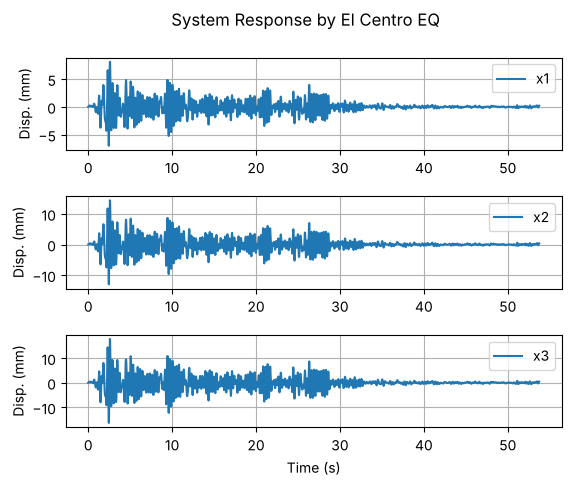

In [20]:
# 해석 결과

import matplotlib.pyplot as plt


plt.subplot(3,1,1)
plt.plot(T, Z[0,:]*1000, label='x1')
plt.ylabel('Disp. (mm)')
plt.legend()
plt.grid()


plt.subplot(3,1,2)
plt.plot(T,Z[1,:]*1000, label='x2')
plt.ylabel('Disp. (mm)')
plt.legend()
plt.grid()


plt.subplot(3,1,3)
plt.plot(T,Z[2,:]*1000, label='x3')
plt.xlabel('Time (s)')
plt.ylabel('Disp. (mm)')
plt.legend()
plt.grid()

plt.subplots_adjust(hspace=0.5)
plt.suptitle('System Response by El Centro EQ', fontsize=12)
plt.show()

# 응답스펙트럼 해석

In [21]:
Ln = phi_n.T@M@np.ones((ndof,1))
Ln

array([[22.46979604],
       [-8.01937736],
       [ 5.54958132]])

In [22]:
# Gamma (모드참여계수)
Gam = np.linalg.inv(Mn)@phi_n.T@M@np.ones((ndof,1))

print(Gam)

[[ 1.22041094]
 [-0.28011019]
 [ 0.05969926]]


In [23]:
RS = np.loadtxt('elcenspec_xi005.dat')  # 엘센트로 지진 응답스펙트럼
RS

array([[1.0000000e-02, 2.0000000e-02, 3.0000000e-02, ..., 3.9800000e+00,
        3.9900000e+00, 4.0000000e+00],
       [8.1255216e-06, 2.8624409e-05, 9.9934263e-05, ..., 1.8877325e-01,
        1.8869040e-01, 1.8859171e-01],
       [3.2078273e+00, 2.8251159e+00, 4.3836073e+00, ..., 4.7047228e-01,
        4.6791154e-01, 4.6533138e-01]], shape=(3, 400))

In [24]:

Tn2 = RS[0,:] # 주기
mD2 = RS[1,:] # 스펙트럴 변위
pA = RS[2,:]  # 스펙트럴 가속도


In [25]:
#Tn1 = np.diag(Tn)  # 구조물 주기
Tn1 = Tn  # 구조물 주기
print(Tn1)

[0.28236378 0.10077447 0.0697381 ]


In [26]:
# Tn1에 해당하는 mD를 보간해서 찾기
from scipy.interpolate import interp1d
import pandas as pd

# 선형 보간 수행
interp_func = interp1d(Tn2, mD2, kind='linear', fill_value="extrapolate")
mD1 = interp_func(Tn1)

# 결측치 선형 보간으로 채우기
mD1 = pd.Series(mD1).interpolate(method='linear').to_numpy()

print(mD1)


[0.01545878 0.00176352 0.0006251 ]


In [27]:
# 각 모드별 최대 유사 가속도 (고유진동수^2 * 스펙트럴 변위)
mA1 = lamda*mD1
print(mA1)

[7.65450328 6.85551827 5.0741795 ]


In [28]:
xmode = np.zeros((ndof,ndof))

In [29]:
# 변위 계산 (모드형상 * 모드참여계수 * 스펙트럴변위)
for ii in range(ndof):
    xmode[:,ii] = phi_n[:,ii]*Gam[ii]*mD1[ii]  # Gam는 계수, mD1은 상수, phi는 벡터

In [30]:
xmode*1000

array([[ 8.39618937,  0.61598459,  0.06724422],
       [15.12941047,  0.27413893, -0.08385217],
       [18.86606627, -0.49398128,  0.03731773]])

In [31]:
# 하중 계산 (밑면전단력: 구조물 강성을 알 때)
Fmode = K@xmode
sum_Fmode = np.sum(Fmode, axis=0)
print(sum_Fmode)

[209.90473436  15.39961463   1.68110549]


In [32]:
# Modal Mass
modal_M =np.zeros(ndof)
for ii in range(ndof):
    modal_M[ii] = ((np.sum(M@phi_n[:,ii]))**2)/(np.sum(M*phi_n[:,ii]**2))

print("Modal Mass: ",modal_M)

Modal Mass:  [27.4223848   2.24630933  0.33130588]


In [33]:
sum(modal_M)

np.float64(30.0)

In [34]:
mA1

array([7.65450328, 6.85551827, 5.0741795 ])

In [35]:
# 모드별 밑면 전단력 (유사가속도와 모달매스를 알 때)
modal_V = mA1*modal_M
print("Modal Base Shear: ",modal_V)

Modal Base Shear:  [209.90473436  15.39961463   1.68110549]


In [36]:
# 조합

SRSS = np.sqrt(sum(modal_V**2))
print("조합 밑면전단력: ",SRSS)

조합 밑면전단력:  210.47558469849938
